In [1]:
try:
    import google.colab  # noqa: F401

    # specify the version of DataEval (==X.XX.X) for versions other than the latest
    %pip install -q dataeval maite-datasets
except Exception:
    pass

In [2]:
import numpy as np
import polars as pl
from dataeval_plots import plot
from IPython.display import display
from maite_datasets.object_detection import VOCDetection

from dataeval import Metadata

# Load the classes from DataEval that are helpful for EDA
from dataeval.config import set_max_processes
from dataeval.core import compute_stats, label_stats
from dataeval.flags import ImageStats
from dataeval.quality import Duplicates, Outliers

# Print all rows of dataframes
_ = pl.Config.set_tbl_rows(-1)

# Set the random value
rng = np.random.default_rng(213)

# Set multiprocessing for DataEval stats
set_max_processes(4)

In [3]:
# Helper method to plot sample images by class
def plot_sample_images_by_class(dataset, image_indices_per_class) -> None:
    import matplotlib.pyplot as plt

    # Plot random images from each category
    _, axs = plt.subplots(5, 4, figsize=(8, 10))

    for ax, (category, indices) in zip(axs.flat, image_indices_per_class.items(), strict=False):
        # Randomly select an index from the list of indices
        ax.imshow(dataset[rng.choice(indices)][0].transpose(1, 2, 0))
        ax.set_title(dataset.metadata["index2label"][category])
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Helper method to plot images of interest
def plot_sample_outlier_images_by_metric(dataset, outlier_result, metric, layout) -> None:
    import matplotlib.gridspec as gridspec
    import matplotlib.pyplot as plt
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    # Filter outliers DataFrame for the specific metric
    metric_outliers = outlier_result.data().filter(pl.col("metric_name") == metric)

    if metric_outliers.is_empty():
        print(f"No images flagged for metric: {metric}")
        return

    # Get all metric values from stored calculation results to understand the distribution
    all_metric_values = outlier_result.calculation_results["stats"][metric]
    quantiles = np.quantile(all_metric_values, [0, 0.25, 0.5, 0.75, 1])
    median = quantiles[2]

    # Compute distance from median and sort by most extreme first
    ranked = (
        metric_outliers
        .unique(subset=["item_index"])
        .with_columns((pl.col("metric_value") - median).abs().alias("_distance"))
        .sort("_distance", descending=True)
        .drop("_distance")
    )

    # Determine number of samples to plot
    n_samples = min(int(np.prod(layout)), ranked.height)

    # Create figure with space for colorbar
    fig = plt.figure(figsize=(12, layout[0] * 4))
    gs = gridspec.GridSpec(
        layout[0],
        layout[1] + 1,
        width_ratios=[1] * layout[1] + [0.05],
        hspace=0.4,
        wspace=0.1,
        left=0.05,
        right=0.92,
        top=0.92,
        bottom=0.02,
    )

    # Create colormap normalization based on full metric distribution
    vmin, vmax = quantiles[0], quantiles[4]
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap("viridis")

    # Plot images
    for i in range(n_samples):
        row = ranked.row(i, named=True)
        img_id = row["item_index"]
        metric_value = row["metric_value"]
        color = cmap(norm(metric_value))

        ax = fig.add_subplot(gs[i // layout[1], i % layout[1]])
        ax.imshow(dataset[img_id][0].transpose(1, 2, 0))
        ax.set_xlabel(f"index: {img_id}\n{metric}: {np.round(metric_value, 3)}", fontsize=9, color="black")
        ax.set_xticks([])
        ax.set_yticks([])

        # Add colored border to indicate extremeness
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(5)
            spine.set_visible(True)

    # Add colorbar with quantile markers
    cbar_ax = fig.add_subplot(gs[:, -1])
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cbar_ax)
    cbar.set_ticks([])

    quantile_labels = ["Min (Q0)", "Q1 (25%)", "Median (Q2)", "Q3 (75%)", "Max (Q4)"]
    for q_val, q_label in zip(quantiles, quantile_labels, strict=False):
        cbar.ax.axhline(q_val, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
        cbar.ax.text(
            1.5,
            q_val,
            f"{q_label}\n{np.round(q_val, 2)}",
            va="center",
            fontsize=8,
            transform=cbar.ax.get_yaxis_transform(),
        )

    fig.suptitle(f'Outlier Images for "{metric}" (sorted by distance from median)', fontsize=12, y=0.99)
    plt.show()

In [4]:
# Download the data and then load it as a torch Tensor
ds = VOCDetection("./data", image_set="train", year="2012", download=True)
print(ds)

VOCDetection Dataset
--------------------
    Year: 2012
    Transforms: []
    Image Set: train
    Metadata: {'id': 'VOCDetection_train', 'index2label': {0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle', 5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow', 10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike', 14: 'person', 15: 'pottedplant', 16: 'sheep', 17: 'sofa', 18: 'train', 19: 'tvmonitor'}, 'split': 'train'}
    Path: /builds/jatic/aria/dataeval/docs/source/notebooks/data/vocdataset/VOCdevkit/VOC2012
    Size: 5717


In [5]:
# Create the Metadata object
md = Metadata(ds)

lstats = label_stats(md.class_labels, md.item_indices, ds.index2label, image_count=len(ds))

# View per_class data as a DataFrame
pl.DataFrame({
    "class_name": list(ds.index2label.values()),
    "label_count": [lstats["label_counts_per_class"][k] for k in ds.index2label],
    "image_count": [lstats["image_counts_per_class"][k] for k in ds.index2label],
})

class_name,label_count,image_count
str,i64,i64
"""aeroplane""",470,328
"""bicycle""",410,281
"""bird""",592,399
"""boat""",508,264
"""bottle""",749,399
"""bus""",317,219
"""car""",1191,621
"""cat""",609,540
"""chair""",1457,656


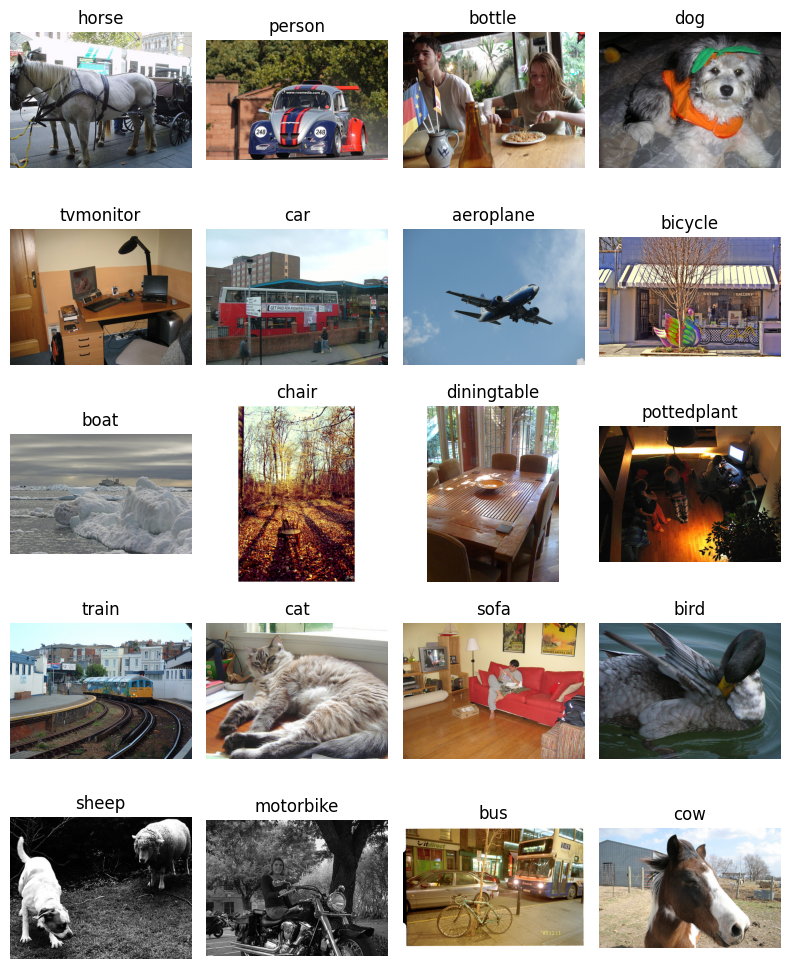

In [6]:
plot_sample_images_by_class(ds, lstats["image_indices_per_class"])

In [7]:
# This cell takes about 1-5 minutes to run depending on your hardware

# Initialize the Outliers class
outliers = Outliers(outlier_threshold="zscore")

# Find the extreme images
outlier_imgs = outliers.evaluate(ds, per_target=False)

# View the number of extreme images
print(f"Number of images with extreme values: {len(outlier_imgs)}")

Number of images with extreme values: 498


In [8]:
# List the metrics with an extreme value
outlier_imgs.aggregate_by_metric()

metric_name,Total
cat,u32
"""size""",173
"""entropy""",124
"""zeros""",100
"""contrast""",92
"""skew""",89
"""kurtosis""",73
"""brightness""",52
"""width""",43
"""var""",35


In [9]:
# List the outliers by class label
outlier_imgs.aggregate_by_class(md)

class_name,aspect_ratio,brightness,contrast,darkness,entropy,height,kurtosis,mean,sharpness,size,skew,std,var,width,zeros,Total
cat,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""person""",2,18,86,16,57,2,48,18,0,126,54,1,9,31,70,538
"""aeroplane""",0,25,6,4,46,5,35,11,0,14,41,7,1,1,4,200
"""bird""",0,17,6,1,27,10,26,1,0,21,32,16,0,1,12,170
"""chair""",0,6,21,4,23,1,10,3,0,16,8,0,2,5,30,129
"""bottle""",3,2,20,6,12,0,12,4,0,12,12,1,4,6,13,107
"""cat""",0,2,10,1,5,6,3,1,0,30,2,3,9,4,11,87
"""car""",0,0,9,2,8,3,3,1,0,27,2,0,4,5,11,75
"""dog""",0,3,4,0,8,2,1,2,3,30,2,3,2,7,6,73
"""boat""",0,2,2,1,9,6,5,1,0,17,6,5,0,0,1,55


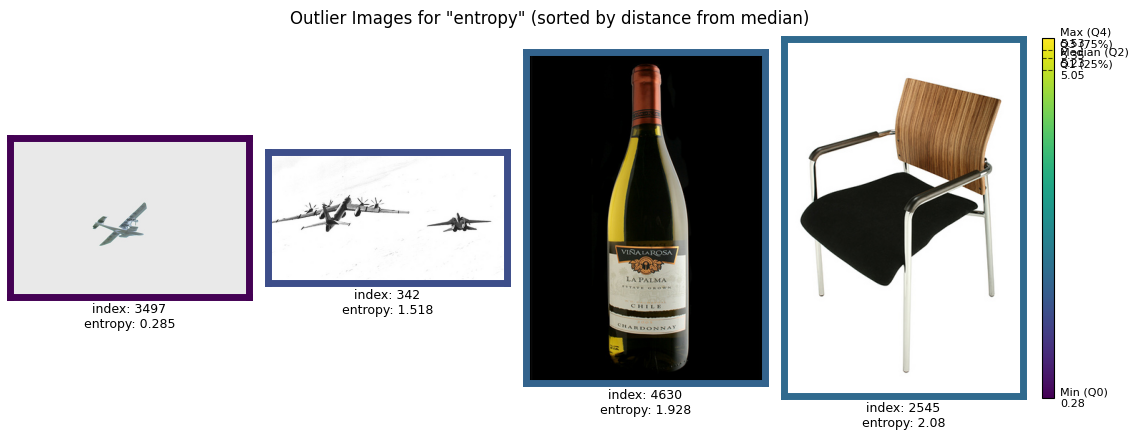

In [10]:
# Plot images flagged for "entropy"
plot_sample_outlier_images_by_metric(ds, outlier_imgs, "entropy", (1, 4))

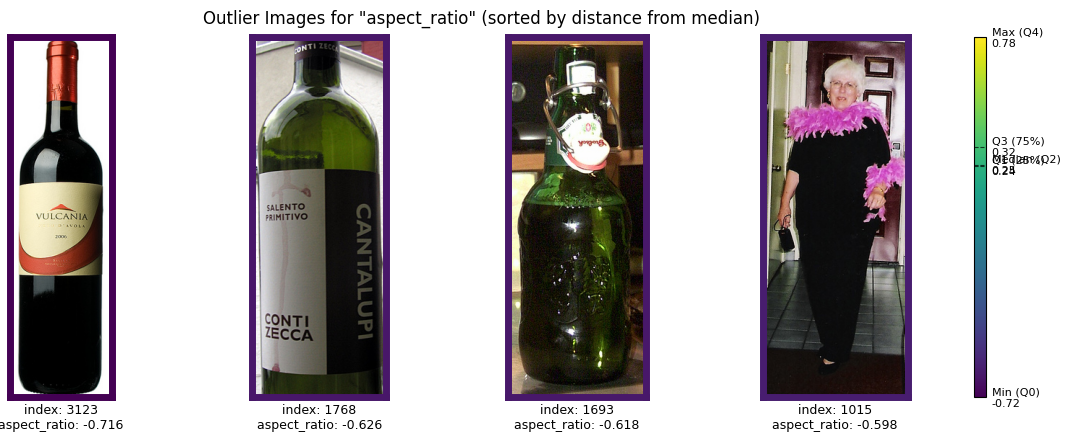

In [11]:
# Plot images flagged for "aspect_ratio"
plot_sample_outlier_images_by_metric(ds, outlier_imgs, "aspect_ratio", (1, 4))

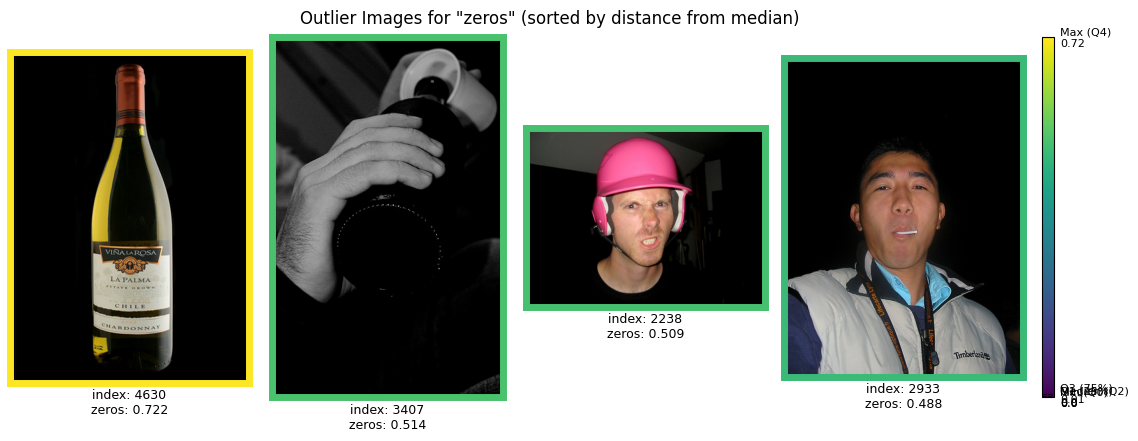

In [12]:
# Plot images flagged for "zeros"
plot_sample_outlier_images_by_metric(ds, outlier_imgs, "zeros", (1, 4))

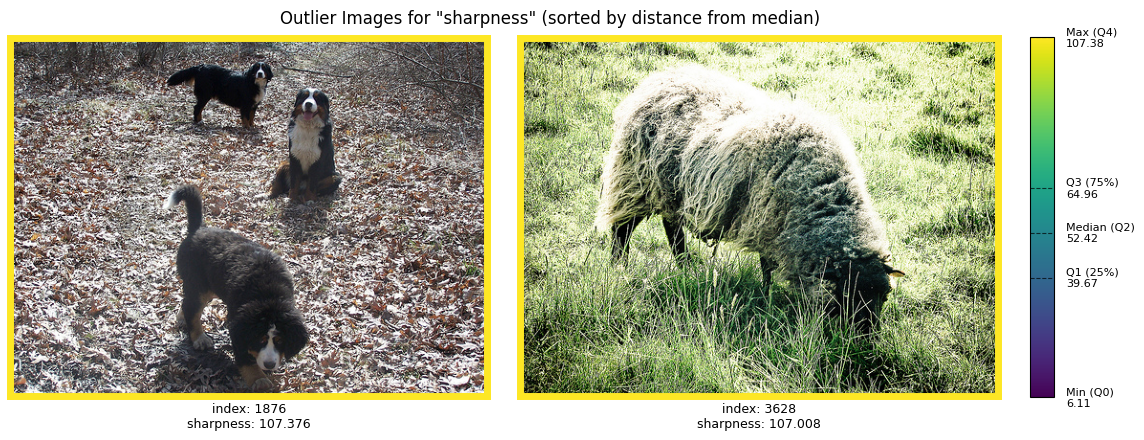

In [13]:
# Plot images flagged for "sharpness"
plot_sample_outlier_images_by_metric(ds, outlier_imgs, "sharpness", (1, 2))

In [14]:
# Initialize the Duplicates class
dups = Duplicates(ImageStats.HASH)

# Find the duplicates
results = dups.evaluate(ds, per_target=False)

In [15]:
# View duplicate groups
display(results)

shape: (1, 6)
┌──────────┬───────┬──────────┬──────────────┬─────────────────────────────────┬─────────────┐
│ group_id ┆ level ┆ dup_type ┆ item_indices ┆ methods                         ┆ orientation │
│ ---      ┆ ---   ┆ ---      ┆ ---          ┆ ---                             ┆ ---         │
│ i64      ┆ str   ┆ str      ┆ list[i64]    ┆ list[str]                       ┆ str         │
╞══════════╪═══════╪══════════╪══════════════╪═════════════════════════════════╪═════════════╡
│ 0        ┆ item  ┆ near     ┆ [1548, 1561] ┆ ["dhash", "dhash_d4", … "phash… ┆ same        │
└──────────┴───────┴──────────┴──────────────┴─────────────────────────────────┴─────────────┘

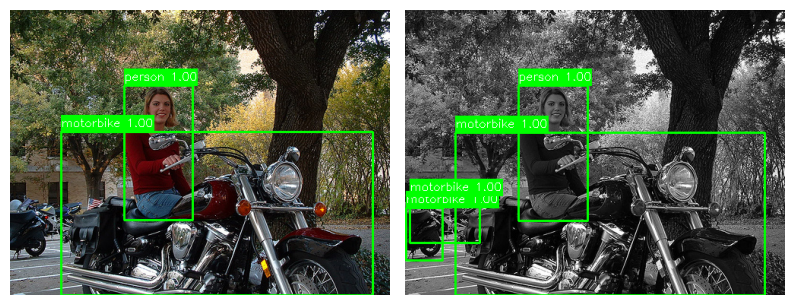

In [16]:
_ = plot(ds, figsize=(12, 6), indices=(1548, 1561))

In [17]:
# Create exact and duplicate images

# Copy images 23 and 46 to create exact duplicates
# Copy and crop images 5 and 4376 to create near duplicates
# Rotate image 100 by 90 degrees to create a rotated duplicate
# Mirror and rotate image 200 to create a mirrored+rotated duplicate
dupes = [
    ds[23][0],  # exact duplicate
    ds[46][0],  # exact duplicate
    ds[5][0][:, 2:-2, 2:-2],  # cropped near duplicate
    ds[4376][0][:, :-5, 5:],  # cropped near duplicate
    np.rot90(ds[100][0], k=1, axes=(1, 2)),  # 90° rotation
    np.flip(np.rot90(ds[200][0], k=2, axes=(1, 2)), axis=2),  # 180° rotation + horizontal flip
]

dupes_stats = compute_stats(dupes, stats=ImageStats.HASH)

/tmp/ipykernel_6965/3784658543.py:16: FutureWarning: The default value of normalize_pixel_values changed to False in v1.1. Pass normalize_pixel_values explicitly to silence this warning. This warning will be removed in v1.2.
  dupes_stats = compute_stats(dupes, stats=ImageStats.HASH)


In [18]:
# Find the duplicates appended to the dataset
duplicates = dups.from_stats([dups.stats, dupes_stats])

# View all duplicate groups
display(duplicates)

shape: (7, 7)
┌──────────┬───────┬──────────┬──────────────┬─────────────────┬─────────────────┬─────────────┐
│ group_id ┆ level ┆ dup_type ┆ item_indices ┆ dataset_indices ┆ methods         ┆ orientation │
│ ---      ┆ ---   ┆ ---      ┆ ---          ┆ ---             ┆ ---             ┆ ---         │
│ i64      ┆ str   ┆ str      ┆ list[i64]    ┆ list[i64]       ┆ list[str]       ┆ str         │
╞══════════╪═══════╪══════════╪══════════════╪═════════════════╪═════════════════╪═════════════╡
│ 0        ┆ item  ┆ exact    ┆ [23, 0]      ┆ [0, 1]          ┆ ["xxhash"]      ┆ null        │
│ 1        ┆ item  ┆ exact    ┆ [46, 1]      ┆ [0, 1]          ┆ ["xxhash"]      ┆ null        │
│ 2        ┆ item  ┆ near     ┆ [5, 2]       ┆ [0, 1]          ┆ ["phash",       ┆ same        │
│          ┆       ┆          ┆              ┆                 ┆ "phash_d4"]     ┆             │
│ 3        ┆ item  ┆ near     ┆ [100, 4]     ┆ [0, 1]          ┆ ["dhash_d4",    ┆ rotated     │
│          ┆    